<a href="https://colab.research.google.com/github/FrankEHA/INGENIERIA_DEL_CONOCIMIENTO/blob/main/TAREA_DIABETES_ARBOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis y comparación de un modelo de clasificación mediante el preprocesamiento de datos

**Autor:** HUAYNALAYA ALONZO FRANK ELVIS


**2. Introducción**

En el presente trabajo se utilizará el conjunto de datos Diabetes, incluido por defecto en el software WEKA, con el propósito de analizar el comportamiento de un modelo de clasificación antes y después de realizar un proceso de limpieza de datos.

El conjunto de datos contiene 768 registros y variables relacionadas con características clínicas de los pacientes. La variable Class corresponde a la clase que se desea predecir.

El trabajo se desarrollará en tres etapas: primero se analizará el conjunto de datos original y se construirá un árbol de decisión; posteriormente se realizará un proceso de limpieza y modificación de los datos para tratar valores que no representan mediciones válidas; finalmente, se volverá a ejecutar el modelo y se compararán los resultados obtenidos en ambas versiones.

**3. Etapa 1 — Dataset original**


En esta primera etapa se trabajará con el conjunto de datos original, sin realizar ninguna modificación o proceso de limpieza.

El objetivo es conocer las características iniciales de los datos y obtener un primer modelo de clasificación que posteriormente pueda ser comparado con el modelo obtenido después del preprocesamiento.


3.1 Carga y exploración del dataset

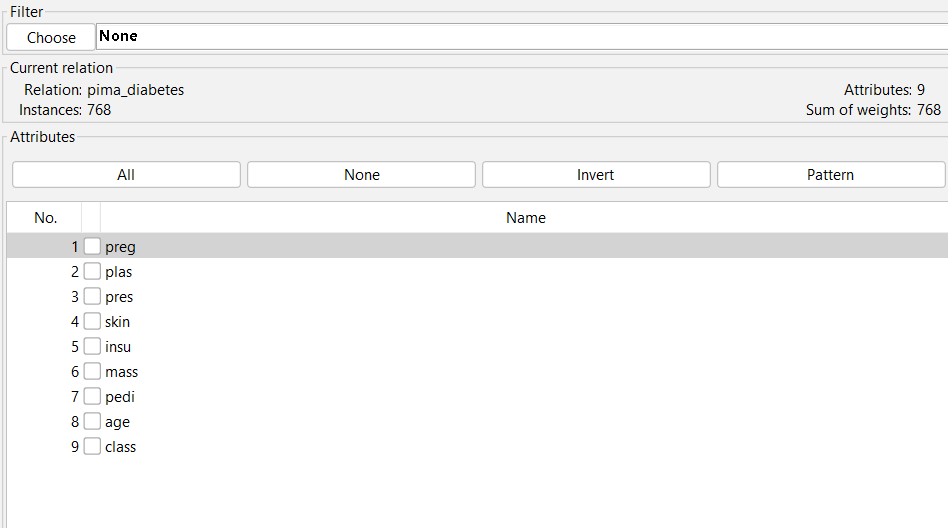

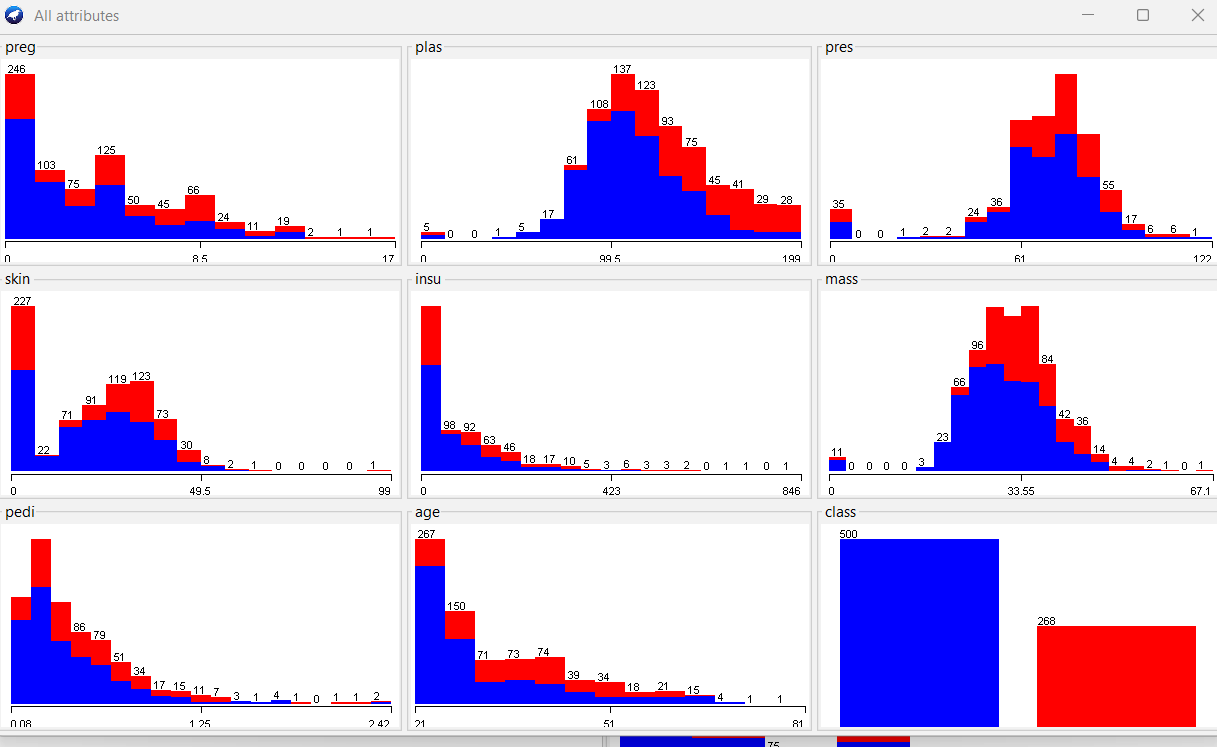

El dataset Diabetes contiene** 768 registros** y las variables utilizadas para el análisis son las siguientes:

**Preg:** número de embarazos.
**Plas:** concentración de glucosa en plasma.
**Pres:** presión arterial diastólica.
**Skin: **grosor del pliegue cutáneo.
**Insu:** concentración de insulina.
**Mass:** índice de masa corporal.
**Pedi: **función de pedigree relacionada con la diabetes.
**Age:** edad.
**Class:** clase correspondiente al resultado de diabetes.

Las primeras ocho variables son de tipo numérico, mientras que Class corresponde a una variable nominal utilizada como variable objetivo de clasificación.

A continuación, se muestra la visualización inicial del dataset en WEKA.

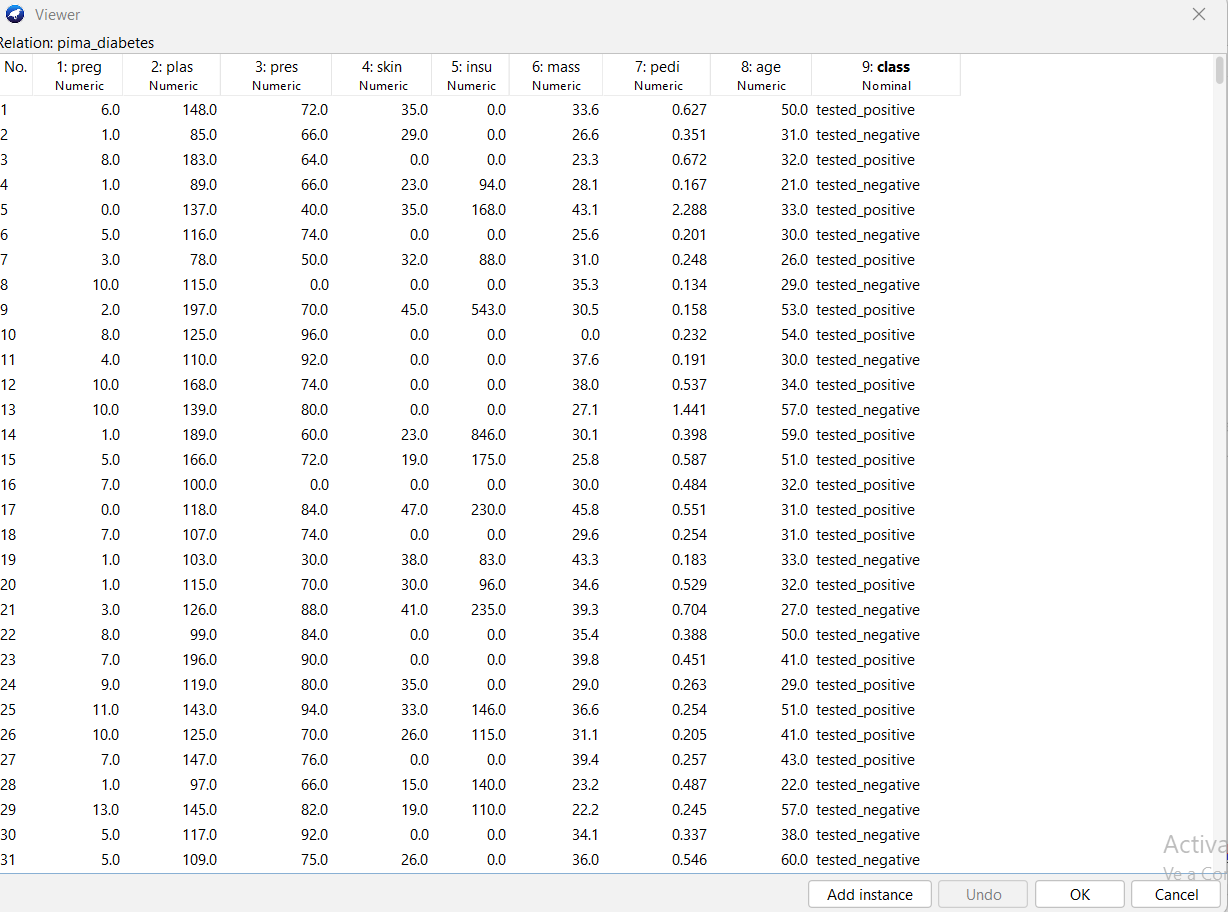

**4. Construcción del árbol original**


Después de revisar los datos originales, se utilizó el algoritmo **J48**, implementación de WEKA del algoritmo de árboles de decisión basado en C4.5.

El modelo se ejecutó utilizando el conjunto de datos original, sin aplicar previamente ningún proceso de limpieza.

A continuación, se presentan los resultados obtenidos por WEKA, incluyendo las métricas de clasificación, la matriz de confusión y el árbol de decisión generado.


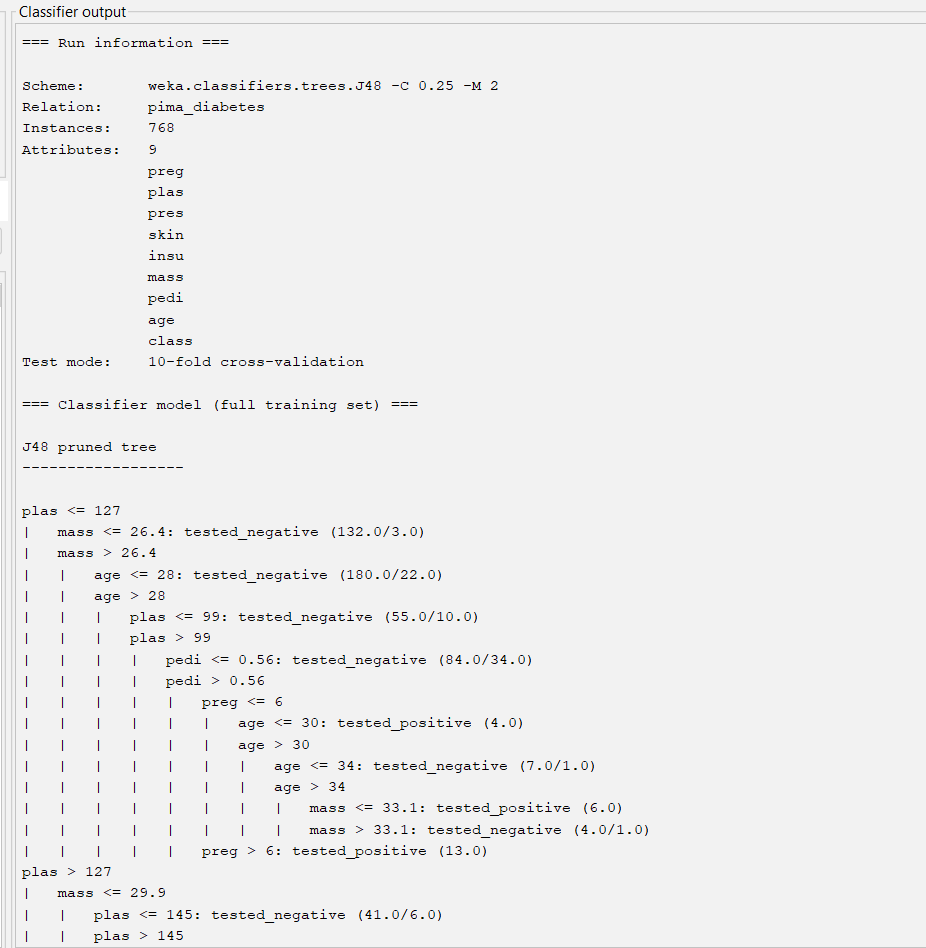

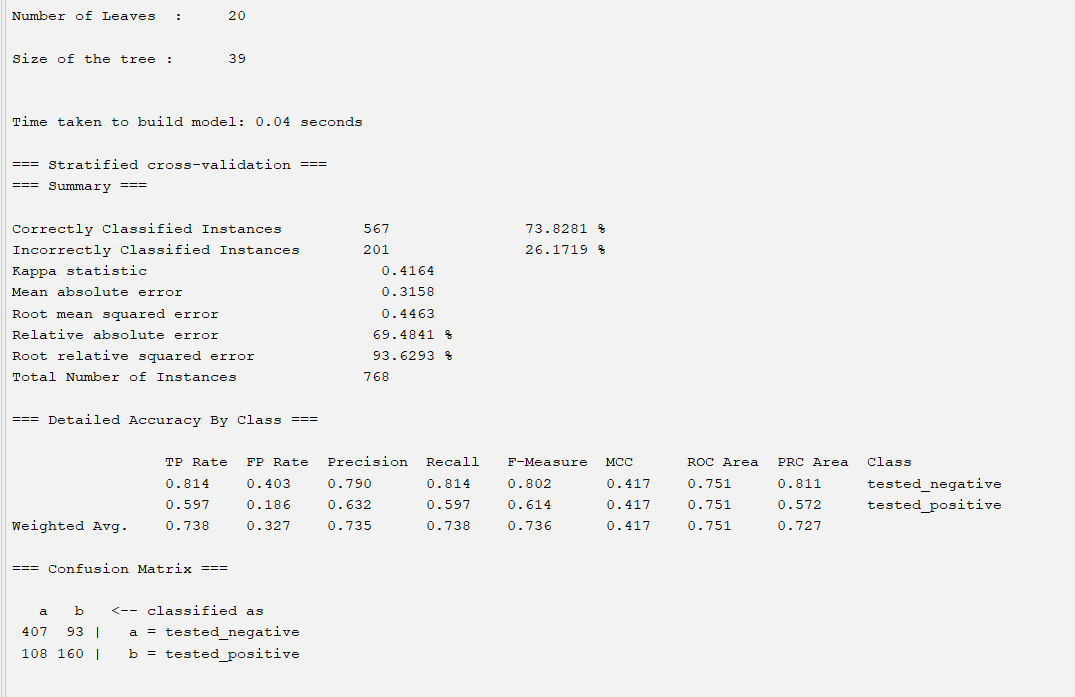

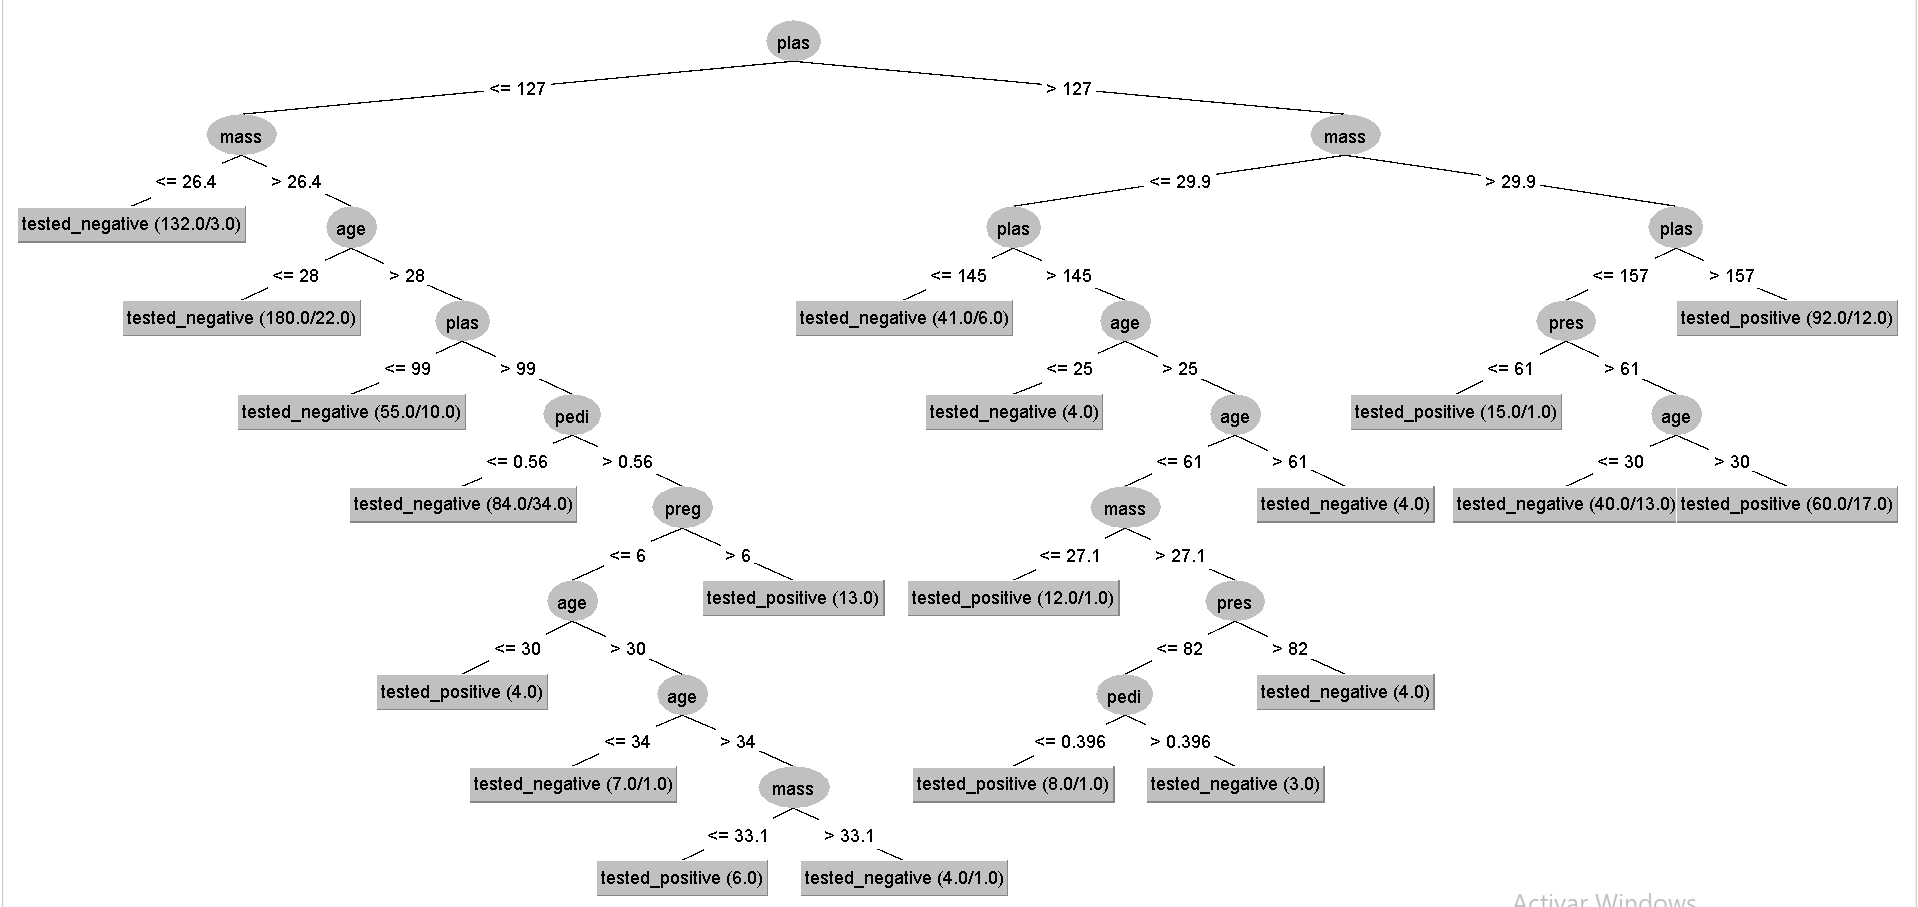

**5. Interpretación del modelo original**



El modelo construido con el dataset original obtuvo una exactitud de **73.8281 %**, clasificando correctamente 567 de las 768 instancias evaluadas.

El árbol utiliza principalmente la concentración de glucosa en plasma (`plas`) como punto inicial de decisión. También utiliza otras variables como el índice de masa corporal (`mass`), la edad (`age`), la función de pedigree (`pedi`), el número de embarazos (`preg`) y la presión arterial (`pres`).

La matriz de confusión permite observar que el modelo identificó correctamente 407 casos negativos y 160 casos positivos. Sin embargo, también se presentaron 93 falsos positivos y 108 falsos negativos.

Estos resultados corresponden al dataset original, por lo que serán utilizados como referencia para evaluar los cambios producidos después del proceso de limpieza de los datos.

# 6. Etapa 2 — Limpieza de datos

En esta segunda etapa se realizará un proceso de limpieza del conjunto de datos con el objetivo de identificar y tratar valores que no representan mediciones válidas.

Durante la exploración del dataset se identificaron valores iguales a 0 en algunas variables. Sin embargo, no todos los valores cero representan errores, por lo que se analizará cada variable antes de decidir cuáles valores deben ser tratados.

**7. Justificación de los valores que serán eliminados**

## 2.1 Identificación de valores inválidos

Se revisó cada variable numérica del dataset para determinar cuántos registros presentaban un valor de 0 y si ese valor tenía sentido fisiológico:

| Variable | Registros con valor 0 | % del total |
|---|---:|---:|
| `plas` | 5 | 0.7 % |
| `pres` | 35 | 4.6 % |
| `mass` | 4 (sobre el subconjunto ya filtrado) | ~0.5 % |
| `skin` | 194–227 | ~25–30 % |
| `insu` | 374–399 | ~49–52 % |

A partir de este análisis se decidió **eliminar únicamente los registros con valor 0 en `plas`, `pres` y `mass`**, ya que en estas tres variables el valor cero:

- No tiene sentido fisiológico (una persona con presión arterial, glucosa en sangre o IMC igual a 0 no podría estar con vida), y
- Representa una proporción muy pequeña del dataset (menos del 5 % en cada caso), por lo que eliminarlos no compromete de forma significativa la cantidad de datos disponibles para entrenar el modelo.

En cambio, **se decidió conservar `skin` e `insu` a pesar de que también presentan valores en 0 sin sentido fisiológico**. La razón es que, en estas dos variables, los ceros no son casos aislados sino que representan aproximadamente entre el 25 % y el 50 % del dataset. Eliminar estos registros reduciría drásticamente el número de instancias disponibles, comprometería el poder estadístico del modelo y probablemente introduciría un sesgo en la muestra restante. Por este motivo, se optó por mantener ambas variables sin modificar, priorizando la representatividad del dataset por sobre una limpieza exhaustiva de todos los valores atípicos.

Por otro lado, la variable `preg` no fue considerada para eliminación, ya que un valor de 0 es perfectamente válido (una persona que no ha tenido embarazos). De igual manera, valores pequeños en `pedi` (como 0.1) tampoco se consideraron errores, dado que esta variable representa un índice que puede tomar valores decimales bajos de forma legítima.

En resumen, las variables utilizadas como criterio de eliminación fueron:

- `plas = 0`
- `pres = 0`
- `mass = 0`

**8. Aplicación de la limpieza**


Utilizando las herramientas de preprocesamiento disponibles en WEKA (Preprocess → Edit), se eliminaron los registros que presentaban un valor de 0 en `pres`, en `mass` y en `plas`, en ese orden.

Se eliminaron 35 instancias por `pres = 0`, 4 instancias adicionales por `mass = 0` y 5 instancias adicionales por `plas = 0`, dando un total de 44 instancias eliminadas.

Las variables `skin` e `insu` se conservaron sin modificaciones, así como los registros con `preg = 0`.

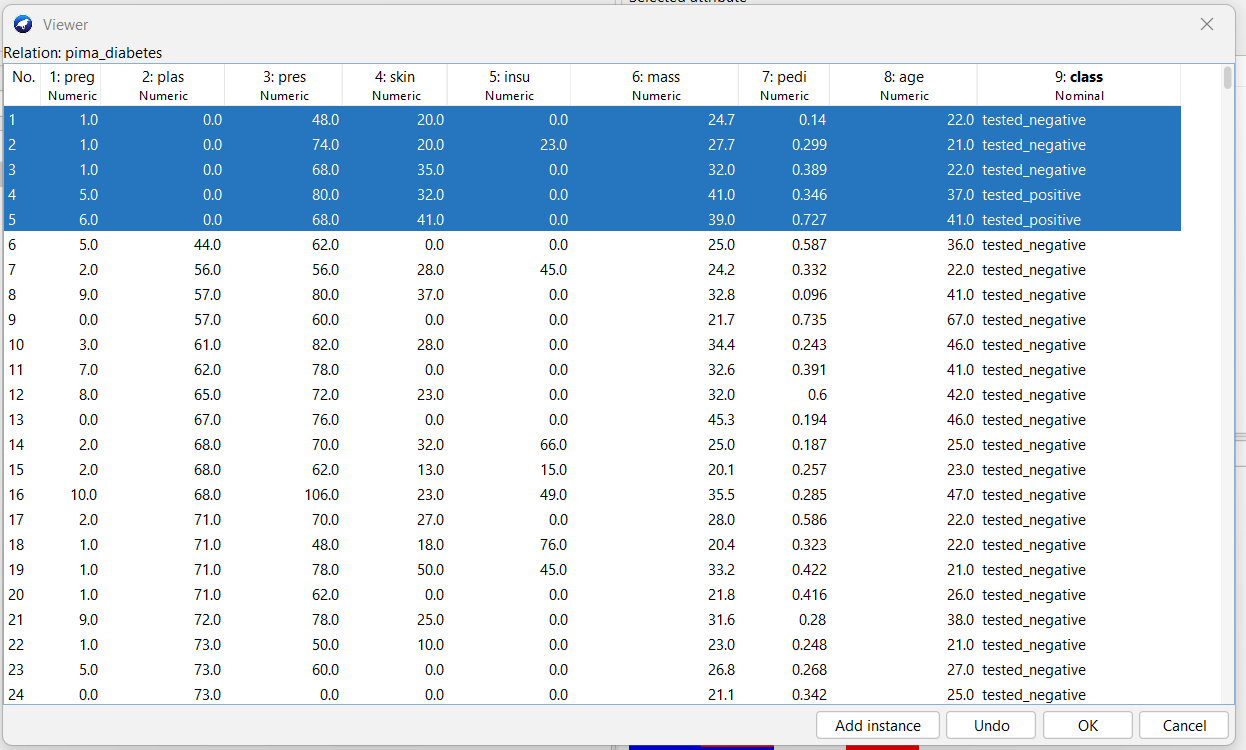

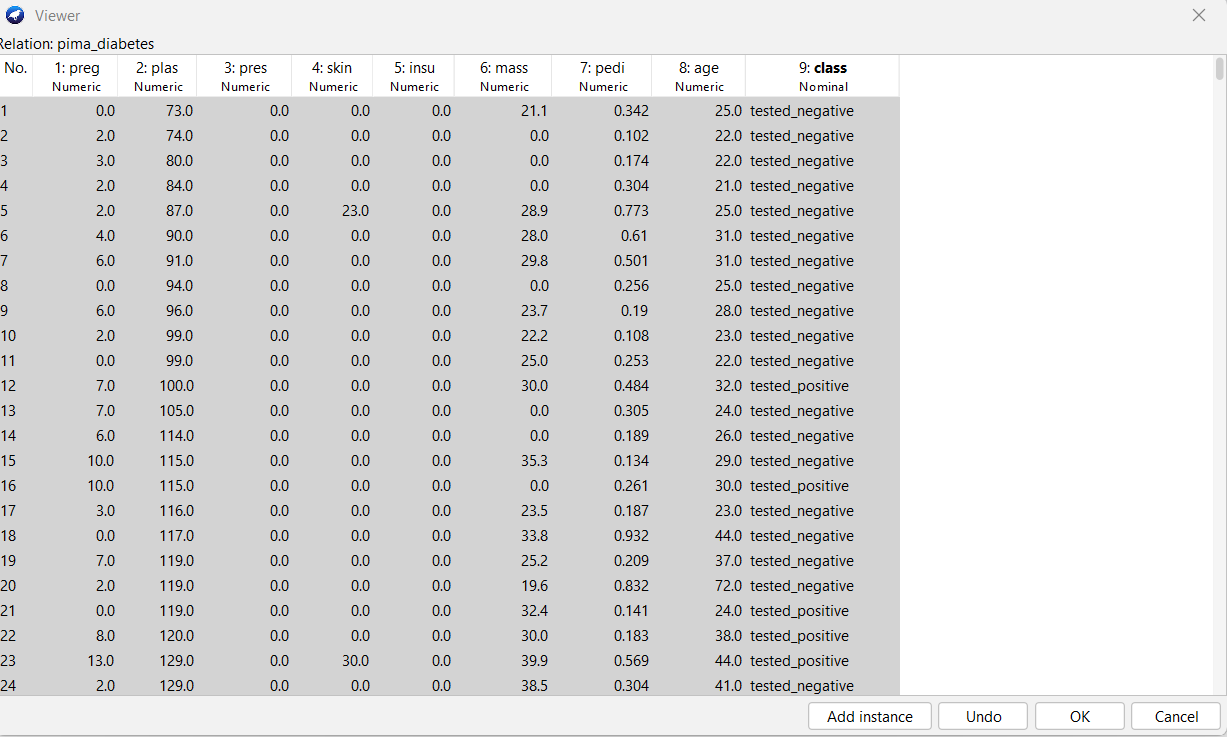


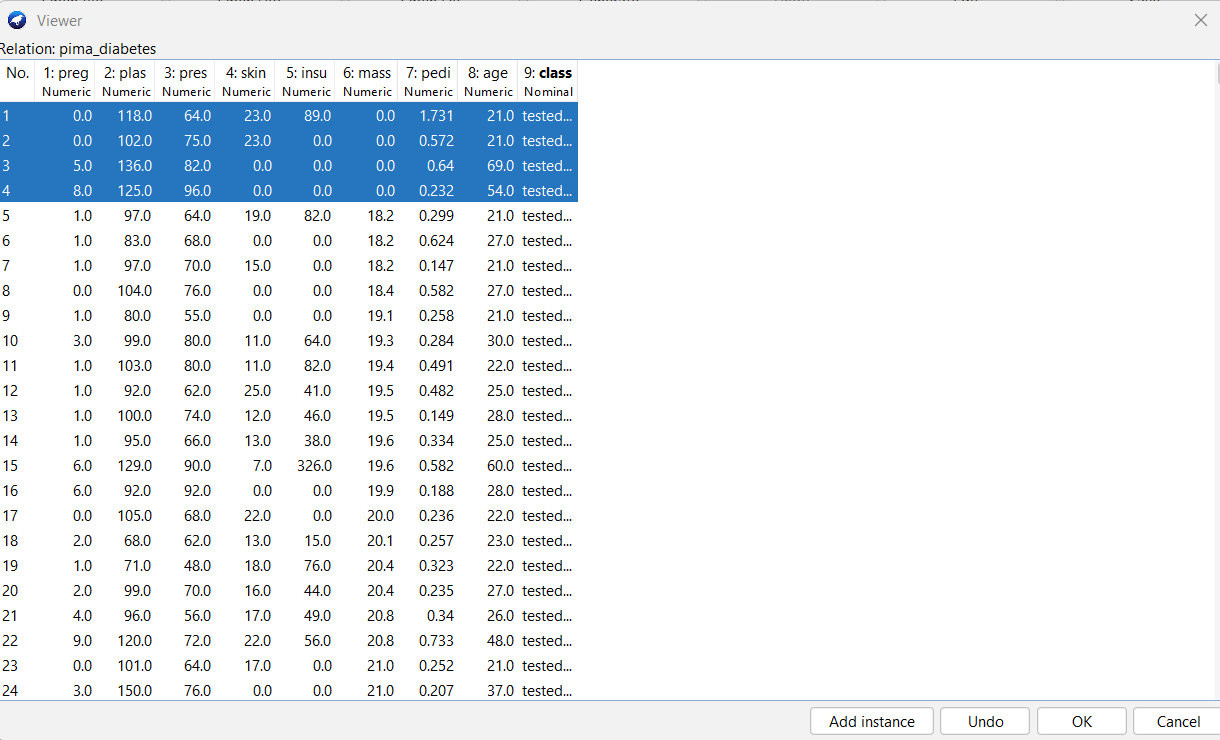

**9. Análisis del dataset limpio**

Después del proceso de limpieza, el dataset quedó reducido de 768 a 724 instancias (se eliminaron 44 registros, equivalentes al 5.7 % del total).

| Característica | Antes de limpiar | Después de limpiar |
|---|---:|---:|
| Instancias | 768 | 724 |
| Atributos | 9 | 9 |
| Variables numéricas | 8 | 8 |
| Variable nominal | 1 | 1 |

Se verificó que las variables `plas`, `pres` y `mass` ya no contuvieran valores en 0, mientras que `skin` e `insu` se mantuvieron sin cambios, tal como se había planificado.

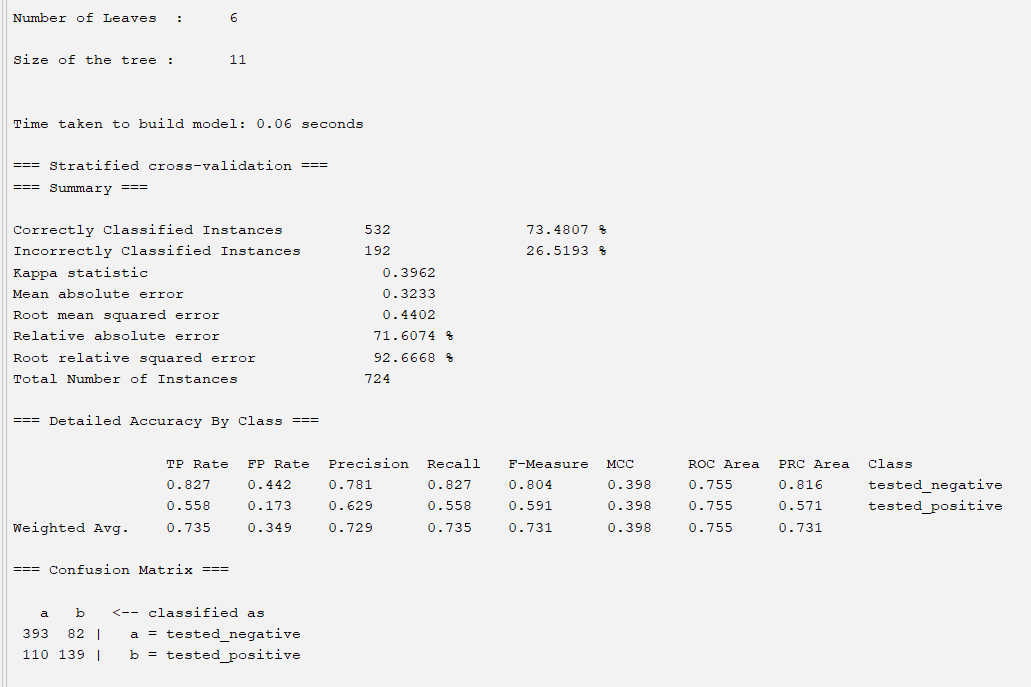



**10. Nuevo árbol de decisión**

Una vez finalizado el proceso de limpieza, se volvió a ejecutar el algoritmo J48 sobre el dataset de 724 instancias, utilizando el mismo procedimiento de validación cruzada estratificada de 10 particiones.

El nuevo árbol quedó compuesto por 11 nodos y solo 6 hojas, una reducción considerable respecto a los 39 nodos y 20 hojas del árbol original.

La raíz del árbol sigue siendo `plas`, aunque con un nuevo umbral de 143 (en lugar de 127). Cuando `plas > 143`, el modelo clasifica directamente como `tested_positive` (171 instancias, 50 clasificadas incorrectamente). Cuando `plas <= 143`, el árbol continúa dividiendo según `mass`, `age` y `pedi`:

- `mass <= 26.3` → `tested_negative` (131 instancias, 3 incorrectas)
- `mass > 26.3` y `age <= 28` → `tested_negative` (210 instancias, 34 incorrectas)
- `mass > 26.3`, `age > 28` y `plas <= 99` → `tested_negative` (51 instancias, 8 incorrectas)
- `mass > 26.3`, `age > 28`, `plas > 99` y `pedi <= 0.527` → `tested_negative` (107 instancias, 44 incorrectas)
- `mass > 26.3`, `age > 28`, `plas > 99` y `pedi > 0.527` → `tested_positive` (54 instancias, 15 incorrectas)

Las variables `preg`, `pres`, `skin` e `insu` dejaron de aparecer en la estructura del árbol.

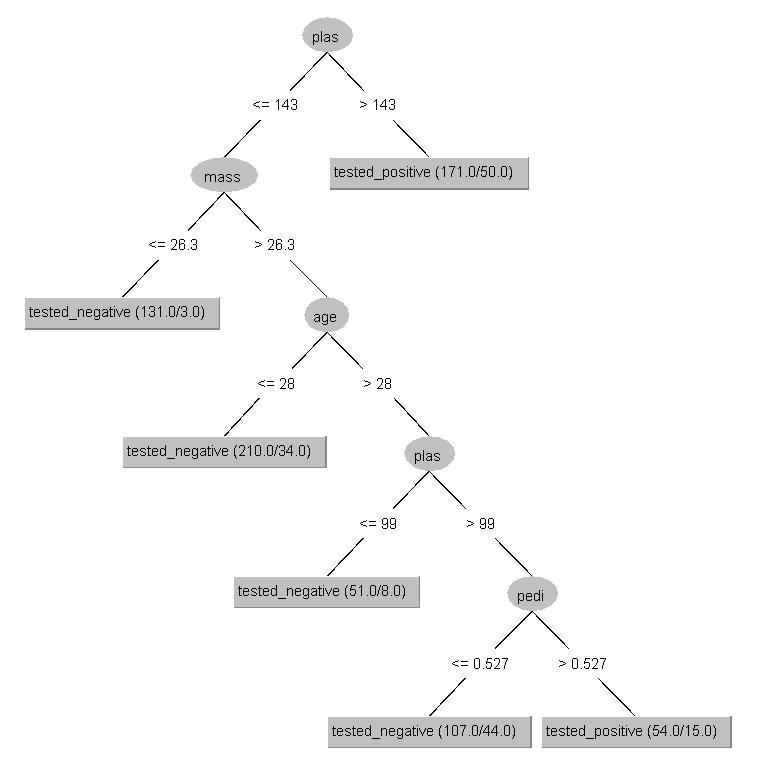

**11. Comparación final**

| Métrica | Dataset original (768) | Dataset limpio (724) |
|---|---:|---:|
| Correctamente clasificadas | 567 | 532 |
| Incorrectamente clasificadas | 201 | 192 |
| Accuracy | 73.83 % | 73.48 % |
| Kappa | 0.4164 | 0.3962 |
| Mean absolute error | 0.3158 | 0.3233 |
| RMSE | 0.4463 | 0.4402 |
| Tamaño del árbol | 39 nodos | 11 nodos |
| Número de hojas | 20 | 6 |
| Falsos positivos | 93 | 82 |
| Falsos negativos | 108 | 110 |
| Recall (clase positiva) | 0.597 | 0.558 |
| Precisión (clase positiva) | 0.632 | 0.629 |

**12. Análisis comparativo**

A diferencia de lo que podría esperarse, el filtrado selectivo de valores imposibles en `plas`, `pres` y `mass` **no mejoró la exactitud del modelo**; de hecho, disminuyó ligeramente, de 73.83 % a 73.48 %. El valor de Kappa también bajó, de 0.4164 a 0.3962, lo que indica una concordancia moderada algo menor entre las predicciones y las clases reales.

Sin embargo, el efecto más relevante del preprocesamiento no está en el accuracy, sino en la **complejidad del árbol**: pasó de 39 nodos y 20 hojas a solamente 11 nodos y 6 hojas, una reducción de más del 70 % en su tamaño. Esto sugiere que buena parte de la estructura del árbol original se dedicaba a memorizar casos particulares y ruido presente en los datos (en parte producido por los propios valores 0 inválidos), en lugar de capturar patrones generalizables de la enfermedad.

En cuanto al error, el RMSE mejoró levemente (de 0.4463 a 0.4402), aunque el error absoluto medio aumentó un poco (de 0.3158 a 0.3233). El recall de la clase positiva bajó de 0.597 a 0.558, y los falsos negativos aumentaron ligeramente en términos relativos, lo que indica que el modelo simplificado tiene algo más de dificultad para detectar los casos positivos, probablemente por contar con una submuestra menor de esa clase tras la limpieza.

En resumen, la limpieza de los datos produjo un modelo **más simple e interpretable, pero no necesariamente más preciso**. Este es un resultado esperable: eliminar registros con valores inválidos reduce el ruido, pero también reduce el volumen de información disponible para el entrenamiento, lo que puede compensar (o incluso superar) la ganancia obtenida al quitar el ruido.

**13. Conclusiones**

El filtrado selectivo de valores imposibles en `plas`, `pres` y `mass` no mejoró el accuracy del modelo; por el contrario, se observó una leve disminución (de 73.83 % a 73.48 %) y una reducción similar en el valor de Kappa (de 0.4164 a 0.3962). Sin embargo, el árbol de decisión resultante fue considerablemente más simple, pasando de 39 nodos y 20 hojas a solo 11 nodos y 6 hojas.

Esto indica que, si bien parte del ruido del dataset original generaba una estructura innecesariamente compleja, la reducción del número de instancias (de 768 a 724) también implicó una pérdida de información que impidió una mejora clara en las métricas de clasificación. En particular, el recall de la clase positiva se vio levemente afectado, bajando de 0.597 a 0.558.

Se decidió no eliminar los registros con valores 0 en `skin` e `insu`, a pesar de no ser fisiológicamente válidos, debido a que representan entre el 25 % y el 50 % del dataset. Eliminarlos habría reducido aún más el tamaño de la muestra disponible, agravando la pérdida de poder estadístico observada con la limpieza aplicada.

En conjunto, el trabajo permite concluir que la limpieza de datos no siempre se traduce en una mejora directa de las métricas de exactitud, pero sí puede aportar un valor importante en términos de interpretabilidad y simplicidad del modelo, lo cual es especialmente relevante en contextos clínicos donde entender las reglas de decisión es tan importante como la precisión del clasificador.